In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
# Import the impdar functions that will be needed
import impdar
from impdar.lib.ApresData.load_apres import load_apres
from impdar.lib.ApresData.load_time_diff import load_time_diff
from impdar.lib.ApresData._ApresDataProcessing import apres_range,stacking,phase2range,phase_uncertainty
from impdar.lib.ApresData._TimeDiffProcessing import range_diff
import sympy
from scipy import optimize,stats
from scipy.io import loadmat
from datetime import datetime, timedelta
import subprocess
from matplotlib.pyplot import cm
import mat73
import pygmt
import pandas as pd
from pyproj import Transformer
from scipy.interpolate import CloughTocher2DInterpolator, interp1d
import matplotlib.colors as colors
import rioxarray as rxr
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031")

In [2]:
import sys
sys.path.append("/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/xapres/")
import pandas as pd
#import ApRESDefs
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import importlib
import gcsfs
import math
import xarray as xr
import xapres as xa
from xapres.utils import generate_range_diff

In [3]:
def custom_stacked_profile_series(chirps,pad=2,F0=2e8,F1=4e8):
    StartFreq = 2e8
    StopFreq = 4e8
    B = StopFreq - StartFreq
    CentreFreq = B/2
    K = 2e8 
    dt = 1/40000
    c0 = 3e8 # speed of light in vaccuum
    ER_ICE = 3.18
    T0 = (F0-StartFreq)/K
    T1 = (F1-StartFreq)/K

    chirps = chirps.isel(chirp_time=range(math.ceil(T0/dt),math.floor(T1/dt)+1)).mean(dim='chirp_num')
    window = np.blackman(len(chirps.chirp_time))
    win_chirps = chirps*window
    Nt = len(chirps.chirp_time)
    Nfft = math.floor(Nt*pad)
    bin2m = c0/(2.*(T1-T0)*pad*math.sqrt(ER_ICE)*K)
    profile_range = np.asarray([i for i in range(Nfft)]) * bin2m      
    profile_range = profile_range[0:math.floor(Nfft/2)-1]
    padchirp = np.zeros((len(chirps.time),Nfft))
    padchirp[:,0:math.floor(Nt/2)] = win_chirps.data[:,math.floor(Nt/2):-1]
    padchirp[:,-math.floor(Nt/2):] = win_chirps.data[:,0:math.floor(Nt/2)]
    p = np.fft.fft(padchirp,axis=1)/Nfft * math.sqrt(2*pad)
    profile = p[:,0:math.floor(Nfft/2)-1]
    m = np.asarray([i for i in range(profile.shape[1])])/pad
    phiref = 2*math.pi*CentreFreq*m/B - m * m * 2*math.pi * K/2/B**2
    profile_ref = profile * np.exp(phiref[np.newaxis,:]*(-1j))
    profile_range = np.asarray([i for i in range(Nfft)]) * bin2m      
    profile_range = profile_range[0:math.floor(Nfft/2)-1]
    n = np.argmin(profile_range<=1400)
    Range = profile_range[:n]
    Profile = profile_ref[:,:n]
    da = xr.DataArray(Profile,
                  dims=['time','profile_range'],
                  coords={'profile_range': Range,
                         'time': chirps.time.data})
    return da
    
def legendre(n, ζ):
    return sympy.functions.special.polynomials.legendre(n, 2 * ζ - 1)
def weight(n, ζ):
    norm = (1 / sympy.integrate(legendre(n, ζ) ** 2, (ζ, 0, 1))) ** 0.5
    return sympy.lambdify(ζ, norm * legendre(n, ζ), "numpy")

def fit_velocities(vel,thickness,plotting=False):
    if ~np.isnan(thickness):
        xdata = vel[0]/thickness
        ydata = vel[1]
        yerr = vel[2]
        ind=(xdata.astype(float)<1.)
        xdata=xdata[ind]
        ydata=ydata[ind]
        yerr=yerr[ind]
        
        ζsym = sympy.symbols("ζsym", real=True, positive=True)
        
        linearfit = lambda ζ, a2, a1: (a2 * weight(1,ζsym)(ζ) + a1*weight(0,ζsym)(ζ))
        squarefit = lambda ζ, b3, b2, b1: (b3*weight(2,ζsym)(ζ) + b2 * weight(1,ζsym)(ζ) + b1*weight(0,ζsym)(ζ))
        cubicfit = lambda ζ, c4, c3, c2, c1: (c4*weight(3,ζsym)(ζ)+ c3*weight(2,ζsym)(ζ) + c2 * weight(1,ζsym)(ζ) + c1*weight(0,ζsym)(ζ))
        quarticfit = lambda ζ, d5, d4, d3, d2, d1: (d5*weight(4,ζsym)(ζ) + d4*weight(3,ζsym)(ζ) + d3*weight(2,ζsym)(ζ) + d2 * weight(1,ζsym)(ζ) + d1*weight(0,ζsym)(ζ))

        # Power-law fitting is best done by first converting
        # to a linear equation and then fitting to a straight line.
        # Note that the `logyerr` term here is ignoring a constant prefactor.
        #
        #  y = a * x^b
        #  log(y) = log(a) + b*log(x)
        #
        # define our (line) fitting function
        
        linearfitfunc = lambda p, ζ: p[0] * weight(0,ζsym)(ζ) + p[1] * weight(1,ζsym)(ζ)
        linearerrfunc = lambda p, ζ, y, err: (y - linearfitfunc(p, ζ))
        squarefitfunc = lambda p, ζ: p[0] * weight(0,ζsym)(ζ) + p[1] * weight(1,ζsym)(ζ) + p[2] * weight(2,ζsym)(ζ)
        squareerrfunc = lambda p, ζ, y, err: (y - squarefitfunc(p, ζ))
        cubicfitfunc = lambda p, ζ: p[0] * weight(0,ζsym)(ζ) + p[1] * weight(1,ζsym)(ζ) + p[2] * weight(2,ζsym)(ζ) + p[3] * weight(3,ζsym)(ζ)
        cubicerrfunc = lambda p, ζ, y, err: (y - cubicfitfunc(p, ζ))
        quarticfitfunc = lambda p, ζ: p[0] * weight(0,ζsym)(ζ) + p[1] * weight(1,ζsym)(ζ) + p[2] * weight(2,ζsym)(ζ) + p[3] * weight(3,ζsym)(ζ) + p[4] * weight(4,ζsym)(ζ)
        quarticerrfunc = lambda p, ζ, y, err: (y - quarticfitfunc(p, ζ))

        pinit_linear = [1.0, -1.0]
        pinit_square = [1.0, -1.0, 0.0]
        pinit_cubic = [1.0, -1.0, 0.0, 0.0]
        pinit_quartic = [1.0, -1.0, 0.0, 0.0,0.0]

        out_linear = optimize.leastsq(linearerrfunc, pinit_linear,
                                args=(xdata, ydata, yerr), full_output=1)
        
        out_square = optimize.leastsq(squareerrfunc, pinit_square,
                                args=(xdata, ydata, yerr), full_output=1)
        
        out_cubic = optimize.leastsq(cubicerrfunc, pinit_cubic,
                                args=(xdata, ydata, yerr), full_output=1)

        out_quartic = optimize.leastsq(quarticerrfunc, pinit_quartic,
                                args=(xdata, ydata, yerr), full_output=1)

        out_list = [out_linear,out_square,out_cubic,out_quartic]

        
        pfinal_linear = out_linear[0]
        covar_linear = out_linear[1]

        pfinal_square = out_square[0]
        covar_square = out_square[1]

        pfinal_cubic = out_cubic[0]
        covar_cubic = out_cubic[1]

        pfinal_quartic = out_quartic[0]
        covar_quartic = out_quartic[1]

        a=[]
        a_err=[]
        b=[]
        b_err=[]
        c=[]
        c_err=[]
        d=[]
        d_err=[]

        for i in range(len(pfinal_linear)):
            a.append(pfinal_linear[i])
            a_err.append(covar_linear[i])

        for i in range(len(pfinal_square)):
            b.append(pfinal_square[i])
            b_err.append(covar_square[i])


        for i in range(len(pfinal_cubic)):
            c.append(pfinal_cubic[i])
            c_err.append(covar_cubic[i])

        for i in range(len(pfinal_quartic)):
            d.append(pfinal_quartic[i])
            d_err.append(covar_quartic[i])

        
        a1 = pfinal_linear[0]
        a2 = pfinal_linear[1]
        
        b1 = pfinal_square[0]
        b2 = pfinal_square[1]
        b3 = pfinal_square[2]

        c1 = pfinal_cubic[0]
        c2 = pfinal_cubic[1]
        c3 = pfinal_cubic[2]
        c4 = pfinal_cubic[3]

        d1 = pfinal_quartic[0]
        d2 = pfinal_quartic[1]
        d3 = pfinal_quartic[2]
        d4 = pfinal_quartic[3]
        d5 = pfinal_quartic[4]
        
        a1Err = np.sqrt( covar_linear[0][0] )
        a2Err = np.sqrt( covar_linear[1][1] )
        
        b1Err = np.sqrt( covar_square[0][0] )
        b2Err = np.sqrt( covar_square[1][1] )
        b3Err = np.sqrt( covar_square[2][2] )

        c1Err = np.sqrt( covar_cubic[0][0] )
        c2Err = np.sqrt( covar_cubic[1][1] )
        c3Err = np.sqrt( covar_cubic[2][2] )
        c4Err = np.sqrt( covar_cubic[3][3] )

        d1Err = np.sqrt( covar_quartic[0][0] )
        d2Err = np.sqrt( covar_quartic[1][1] )
        d3Err = np.sqrt( covar_quartic[2][2] )
        d4Err = np.sqrt( covar_quartic[3][3] )
        d5Err = np.sqrt( covar_quartic[4][4] )
        

        ##########
        # Plotting data
        ##########
        if plotting==True:
            plt.clf()
            fig, ax = plt.subplots(figsize=(3,3),dpi=200)
            ax.plot(linearfit(xdata, a[0], a[1]),xdata)     # Fit
            ax.plot(squarefit(xdata, b[2], b[1], b[0]),xdata)     # Fit
            ax.plot(cubicfit(xdata, c[3], c[2], c[1], c[0]),xdata) 
            ax.plot(quarticfit(xdata, d[4], d[3], d[2], d[1], d[0]),xdata) 

            ax.errorbar(ydata,xdata, xerr=yerr, fmt='k.')  # Data
            xlims=ax.get_xlim()

            plt.text(xlims[1]/2+(xlims[1]-xlims[0])*(-.2), .075, 'a1 = %2.4f +/- %2.4f' % (a[0], a_err[0]),fontsize=10)
            plt.text(xlims[1]/2+(xlims[1]-xlims[0])*(-.2), .05, 'a2 = %2.4f +/- %2.4f' % (a[1], a_err[1]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .05, 'b1 = %2.4f +/- %2.4f' % (b[0], b_err[0]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .075, 'b2 = %2.4f +/- %2.4f' % (b[1], b_err[1]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'b3 = %2.4f +/- %2.4f' % (b[2], b_err[2]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .05, 'c1 = %2.4f +/- %2.4f' % (c[0], c_err[0]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .075, 'c2 = %2.4f +/- %2.4f' % (c[1], c_err[1]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'c3 = %2.4f +/- %2.4f' % (c[2], c_err[2]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'c4 = %2.4f +/- %2.4f' % (c[3], c_err[3]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .05, 'd1 = %2.4f +/- %2.4f' % (d[0], d_err[0]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .075, 'd2 = %2.4f +/- %2.4f' % (d[1], d_err[1]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'd3 = %2.4f +/- %2.4f' % (d[2], d_err[2]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'd4 = %2.4f +/- %2.4f' % (d[3], d_err[3]),fontsize=10)
            plt.text(xlims[0]+(xlims[1]-xlims[0])*.01, .1, 'd5 = %2.4f +/- %2.4f' % (d[4], d_err[4]),fontsize=10)

            
            plt.title('Linear and quadratic least squares models')
            plt.xlabel('velocity.(m/yr)')
            plt.ylabel('depth.(normalized to thickness)')
            plt.grid()
            plt.ylim(0.0,1)
            plt.gca().invert_yaxis()

        f_test=[]
        f_prob=[]

        for i in range(len(out_list)-1):
            f_test_tmp=((np.sum(out_list[i][2]['fvec']**2/yerr**2) - np.sum(out_list[i][2]['fvec']**2/yerr**2))/(3-2)/(np.sum(out_list[i+1][2]['fvec']**2/yerr**2)/(len(out_list[i+1][2]['fvec'])-3)))
            f_prob.append( 1-stats.f.cdf(f_test_tmp, 3-2, len(out_list[i+1][2]['fvec'])-3))
            f_test.append(f_test_tmp)
    else:
        a, b, c, d, a_err, b_err, c_err, d_err, f_test, f_prob = repeat(np.nan, 10)
    #print(m, b, c1, c2, c3, mErr, bErr, c1Err, c2Err, c3Err, f_test, f_prob)
    return a, b, c, d, a_err, b_err, c_err, d_err, f_test, f_prob

from scipy.stats import f

# Function to compute the F-statistic and corresponding p-value
def calculate_f_test(ssr1, ssr2, df1, df2):
    """
    Perform F-test to evaluate whether adding higher-order terms is significant.

    Parameters:
    - ssr1: Sum of squared residuals for the simpler (lower-order) model.
    - ssr2: Sum of squared residuals for the complex (higher-order) model.
    - df1: Degrees of freedom of the simpler model.
    - df2: Degrees of freedom of the complex model.

    Returns:
    - f_stat: Computed F-statistic.
    - p_value: p-value for the F-test.
    """
    numerator = (ssr1 - ssr2) / (df2 - df1)
    denominator = ssr2 / df2
    f_stat = numerator / denominator
    p_value = 1 - f.cdf(f_stat, df2 - df1, df2)
    return f_stat, p_value


def fit_velocities_v2(vel, thickness, plotting=False):
    if not np.isnan(thickness):
        xdata = vel[0] / thickness
        ydata = vel[1]
        yerr = vel[2]

        # Filter data where normalized depth exceeds 1
        ind = xdata.astype(float) < 1.0
        xdata = xdata[ind]
        ydata = ydata[ind]
        yerr = yerr[ind]

        ζsym = sympy.symbols("ζsym", real=True, positive=True)

        # Define fitting functions
        linearfitfunc = lambda p, ζ: p[0] * weight(0, ζsym)(ζ) + p[1] * weight(1, ζsym)(ζ)
        squarefitfunc = lambda p, ζ: (
            p[0] * weight(0, ζsym)(ζ) + p[1] * weight(1, ζsym)(ζ) + p[2] * weight(2, ζsym)(ζ)
        )
        cubicfitfunc = lambda p, ζ: (
            p[0] * weight(0, ζsym)(ζ)
            + p[1] * weight(1, ζsym)(ζ)
            + p[2] * weight(2, ζsym)(ζ)
            + p[3] * weight(3, ζsym)(ζ)
        )
        quarticfitfunc = lambda p, ζ: (
            p[0] * weight(0, ζsym)(ζ)
            + p[1] * weight(1, ζsym)(ζ)
            + p[2] * weight(2, ζsym)(ζ)
            + p[3] * weight(3, ζsym)(ζ)
            + p[4] * weight(4, ζsym)(ζ)
        )

        # Define residual functions
        linearerrfunc = lambda p, ζ, y, err: (y - linearfitfunc(p, ζ))
        squareerrfunc = lambda p, ζ, y, err: (y - squarefitfunc(p, ζ))
        cubicerrfunc = lambda p, ζ, y, err: (y - cubicfitfunc(p, ζ))
        quarticerrfunc = lambda p, ζ, y, err: (y - quarticfitfunc(p, ζ))

        # Initial parameter guesses
        pinit_linear = [1.0, -1.0]
        pinit_square = [1.0, -1.0, 0.0]
        pinit_cubic = [1.0, -1.0, 0.0, 0.0]
        pinit_quartic = [1.0, -1.0, 0.0, 0.0, 0.0]

        # Fit the models
        out_linear = optimize.leastsq(linearerrfunc, pinit_linear, args=(xdata, ydata, yerr), full_output=1)
        out_square = optimize.leastsq(squareerrfunc, pinit_square, args=(xdata, ydata, yerr), full_output=1)
        out_cubic = optimize.leastsq(cubicerrfunc, pinit_cubic, args=(xdata, ydata, yerr), full_output=1)
        out_quartic = optimize.leastsq(quarticerrfunc, pinit_quartic, args=(xdata, ydata, yerr), full_output=1)

        out_list = [out_linear, out_square, out_cubic, out_quartic]

        # Extract fit parameters and covariance matrices
        fit_params = [out[0] for out in out_list]
        cov_matrices = [out[1] for out in out_list]

        # Residuals (RSS) and parameter counts
        residuals = [np.sum(out[2]['fvec'] ** 2) for out in out_list]  # RSS for each model
        params_count = [len(out[0]) for out in out_list]               # Number of parameters
        
        # Degrees of freedom
        n_data = len(xdata)  # Number of data points
        dfs = [n_data - p for p in params_count]
        
        # Calculate F-tests
        f_tests = []
        p_values = []
        for i in range(len(out_list) - 1):
            ssr_simple = residuals[i]
            ssr_complex = residuals[i + 1]
            df_simple = dfs[i]
            df_complex = dfs[i + 1]
            delta_df = df_simple - df_complex  # Difference in degrees of freedom
        
            # Ensure degrees of freedom are valid
            if delta_df > 0 and df_complex > 0:
                f_stat = ((ssr_simple - ssr_complex) / delta_df) / (ssr_complex / df_complex)
                p_value = 1 - stats.f.cdf(f_stat, delta_df, df_complex)
            else:
                f_stat, p_value = np.nan, np.nan
        
            f_tests.append(f_stat)
            p_values.append(p_value)

        

        # Plotting
        if plotting:
            plt.clf()
            fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

            # Generate fitted lines for plotting
            ζ_vals = np.linspace(0, 1, 500)
            ax.plot(linearfitfunc(fit_params[0], ζ_vals), ζ_vals, label="Linear Fit")
            ax.plot(squarefitfunc(fit_params[1], ζ_vals), ζ_vals, label="Quadratic Fit")
            ax.plot(cubicfitfunc(fit_params[2], ζ_vals), ζ_vals, label="Cubic Fit")
            ax.plot(quarticfitfunc(fit_params[3], ζ_vals), ζ_vals, label="Quartic Fit")

            # Plot data points
            ax.errorbar(ydata, xdata, xerr=yerr, fmt="k.", label="Data")
            ax.invert_yaxis()
            ax.set_xlabel("Velocity (m/yr)")
            ax.set_ylabel("Depth (normalized to thickness)")
            ax.grid()
            ax.legend()
            plt.title("Fitted Models with Increasing Polynomial Order")
            plt.show()

        return out_linear[0], out_square[0], out_cubic[0], out_quartic[0], out_linear[1], out_square[1], out_cubic[1], out_quartic[1], f_tests, p_values
    else:
        # Handle invalid thickness
        return repeat(np.nan, 10)



In [4]:
ζsym = sympy.symbols("ζsym", real=True, positive=True)


linearfit = lambda ζ, a2, a1: (a2 * weight(1,ζsym)(ζ) + a1*weight(0,ζsym)(ζ))
squarefit = lambda ζ, b3, b2, b1: (b3*weight(2,ζsym)(ζ) + b2 * weight(1,ζsym)(ζ) + b1*weight(0,ζsym)(ζ))
cubicfit = lambda ζ, c4, c3, c2, c1: (c4*weight(3,ζsym)(ζ)+ c3*weight(2,ζsym)(ζ) + c2 * weight(1,ζsym)(ζ) + c1*weight(0,ζsym)(ζ))
quarticfit = lambda ζ, d5, d4, d3, d2, d1: (d5*weight(4,ζsym)(ζ) + d4*weight(3,ζsym)(ζ) + d3*weight(2,ζsym)(ζ) + d2 * weight(1,ζsym)(ζ) + d1*weight(0,ζsym)(ζ))


In [5]:
filenames=glob.glob('../data/Strain/*')
filenames2223 = glob.glob('../data/Strain/')

In [6]:
df=[]
for file in filenames:
    mat=mat73.loadmat(file)
    df.append(mat)
    mat=[]

In [7]:

a=[]
b=[]
c=[]
d=[]
a_err=[]
b_err=[]
c_err=[]
d_err=[]
f_test=[]
f_prob=[]


for dat in df:
    
    vel=np.array([dat['vdat_strain']['range'],dat['vdat_strain']['dh']*365/dat['vdat_strain']['dt'],dat['vdat_strain']['dhe']*365/dat['vdat_strain']['dt']])
    a_tmp, b_tmp, c_tmp, d_tmp, a_err_tmp, b_err_tmp, c_err_tmp, d_err_tmp, f_test_tmp, f_prob_tmp=fit_velocities_v2(vel,dat['vdat_strain']['H'])
    plt.subplots()
    plt.plot(linearfit(dat['vdat_strain']['range']/dat['vdat_strain']['H'], a_tmp[1], a_tmp[0]),dat['vdat_strain']['range'],color='coral',lw=1,label='linear')
    plt.plot(squarefit(dat['vdat_strain']['range']/dat['vdat_strain']['H'], b_tmp[2],b_tmp[1],b_tmp[0]),dat['vdat_strain']['range'],color='mediumpurple',lw=1,label='quadratic')
    plt.plot(cubicfit(dat['vdat_strain']['range']/dat['vdat_strain']['H'], c_tmp[3],c_tmp[2],c_tmp[1],c_tmp[0]),dat['vdat_strain']['range'],color='dodgerblue',lw=1,label='cubic')
    plt.plot(quarticfit(dat['vdat_strain']['range']/dat['vdat_strain']['H'], d_tmp[4],d_tmp[3],d_tmp[2],d_tmp[1],d_tmp[0]),dat['vdat_strain']['range'],color='forestgreen',lw=1,label='quartic')

    a.append(a_tmp)
    b.append(b_tmp)
    c.append(c_tmp)
    d.append(d_tmp)
    a_err.append(a_err_tmp)
    b_err.append(b_err_tmp)
    c_err.append(c_err_tmp)
    d_err.append(d_err_tmp)
    f_test.append(f_test_tmp)
    f_prob.append(f_prob_tmp)
    plt.gca().invert_yaxis()
    plt.xlabel('vertical velocity (m/yr)')
    plt.ylabel('depth (m)')

    plt.legend()
    
    dat['vdat_strain']['Name']
    plt.plot(dat['vdat_strain']['dh']*365.35/dat['vdat_strain']['dt'],dat['vdat_strain']['range'],'.',color='k',ms=2,zorder=1,alpha=.5)
    plt.savefig('../figures/'+dat['vdat_strain']['Name']+'.png')
    plt.close()

In [8]:
waypoints=pd.read_excel('/home/andrew/Downloads/Waypoints_GHOST2022-2023.xlsx','waypoint-gps')

In [9]:
waypoints

,Waypoint,xcoord,ycoord,zcoord,Repeated
0,G1-21-05,-107.571318,-76.002191,882.202698,1
1,G1-22-05,NaN,NaN,890.111603,1
2,G1-23-05,-107.576420,-76.011062,898.020508,1
3,G1-24-05,-107.579000,-76.015486,892.305969,1
4,G1-25-05,-107.581394,-76.019930,892.733093,1
...,...,...,...,...,...
230,221,-109.029264,-77.571790,1357.663574,NaN
231,220,-109.037602,-77.580705,1346.282715,NaN
232,219,-109.045977,-77.589632,1340.057617,NaN
233,218,-109.054292,-77.598552,1318.649536,NaN


In [10]:
Names=[]
for dat in df:
    Names.append(dat['vdat_strain']['Name'])

In [11]:
mask=waypoints['Waypoint'].isin(Names)

In [12]:
repeats=waypoints[mask].drop('Repeated',axis=1)

In [13]:
i=0
for dat in df:
    ind=repeats['Waypoint'].isin([dat['vdat_strain']['Name']])
    print(ind)
    repeats.loc[ind,'a1']=a[i][0]
    repeats.loc[ind,'a2']=a[i][1]
    repeats.loc[ind,'b1']=b[i][0]
    repeats.loc[ind,'b2']=b[i][1]
    repeats.loc[ind,'b3']=b[i][2]
    repeats.loc[ind,'c1']=c[i][0]
    repeats.loc[ind,'c2']=c[i][1]
    repeats.loc[ind,'c3']=c[i][2]
    repeats.loc[ind,'c4']=c[i][3]
    repeats.loc[ind,'d1']=d[i][0]
    repeats.loc[ind,'d2']=d[i][1]
    repeats.loc[ind,'d3']=d[i][2]
    repeats.loc[ind,'d4']=d[i][3]
    repeats.loc[ind,'d5']=d[i][4]
    repeats.loc[ind,'f_test1']=f_test[i][0]
    repeats.loc[ind,'f_test2']=f_test[i][1]
    repeats.loc[ind,'f_test3']=f_test[i][2]
    repeats.loc[ind,'f_prob1']=f_prob[i][0]
    repeats.loc[ind,'f_prob2']=f_prob[i][1]
    repeats.loc[ind,'f_prob3']=f_prob[i][2]
    i=i+1

0      False
1      False
3      False
4      False
5      False
       ...  
119    False
121    False
123    False
127    False
129    False
Name: Waypoint, Length: 91, dtype: bool
0      False
1      False
3      False
4      False
5      False
       ...  
119    False
121    False
123    False
127    False
129    False
Name: Waypoint, Length: 91, dtype: bool
0      False
1      False
3      False
4      False
5      False
       ...  
119    False
121    False
123    False
127    False
129     True
Name: Waypoint, Length: 91, dtype: bool
0      False
1      False
3      False
4      False
5      False
       ...  
119    False
121    False
123    False
127    False
129    False
Name: Waypoint, Length: 91, dtype: bool
0      False
1      False
3      False
4      False
5      False
       ...  
119    False
121    False
123    False
127    False
129    False
Name: Waypoint, Length: 91, dtype: bool
0      False
1      False
3      False
4      False
5      False
       ...  
119    

In [14]:
repeats['xcoord_stereo'],repeats['ycoord_stereo']=transformer.transform(repeats['ycoord'],repeats['xcoord'])
repeats['distance']=np.nan
ind=~np.isnan(repeats['xcoord_stereo'])
repeats['distance'][ind]=abs(np.cumsum(np.insert(np.diff(np.sqrt(repeats['xcoord_stereo'][ind]**2+repeats['ycoord_stereo'][ind]**2)),0,0)))

/tmp/ipykernel_13717/141252120.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  repeats['distance'][ind]=abs(np.cumsum(np.insert(np.diff(np.sqrt(repeats['xcoord_stereo'][ind]**2+repeats['ycoord_stereo'][ind]**2)),0,0)))
/tmp/ipykernel_137

In [15]:
ds=xr.open_dataset('/home/andrew/Downloads/BedMachineAntarctica-v3.nc')

In [16]:
bed=ds['bed'].sel(x=repeats['xcoord_stereo'].to_xarray(),y=repeats['ycoord_stereo'].to_xarray(),method='nearest')
surface=ds['surface'].sel(x=repeats['xcoord_stereo'].to_xarray(),y=repeats['ycoord_stereo'].to_xarray(),method='nearest')

In [17]:
filenames22=glob.glob('/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/*/*.dat')

In [18]:
G=[]
Gnames=[]
for i, file in enumerate(filenames22):
    
    print(file)
    G_tmp = load_apres([file])
    apres_range(G_tmp,2)
    G.append(G_tmp)
    Gnames.append(file[61:69])
    print(Gnames)
    
    

/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G2-22-05/DATA2023-12-23_225621_G2-22-05.dat
['G2-22-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G2-01-05/DATA2023-12-24_024241_G2-01-05.dat
['G2-22-05', 'G2-01-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G1-31-05/DATA2023-12-25_220040_G1-31-05.dat
['G2-22-05', 'G2-01-05', 'G1-31-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G1-26-05/DATA2023-12-25_230626_G1-26-05.dat
['G2-22-05', 'G2-01-05', 'G1-31-05', 'G1-26-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G1-29-05/DATA2023-12-25_223803_G1-29-05.dat
['G2-22-05', 'G2-01-05', 'G1-31-05', 'G1-26-05', 'G1-29-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G1-27-05/DATA2023-12-25_225634_G1-27-05.dat
['G2-22-05', 'G2-01-05', 'G1-31-05', 'G1-26-05', 'G1-29-05', 'G1-27-05']
/home/andrew/Downloads/ITGC-GHOST-pRES/Measurements/Raw/2024/G2-02-05/DATA2023-12-24_023244_G2-02-05.dat
['G2-22

In [19]:
x=[]
y=[]
z=[]
err=[]
amp=[]
surface=[]
thickness=[]
distance=[]
x_raw=[]
fig, (ax1,ax2,ax3)=plt.subplots(3,1,sharex=True)
cmap = cm.coolwarm
cmap_radar = cm.grey
cmap_err = cm.plasma
for i, dat in enumerate(df):
    ind=repeats['Waypoint']==dat['vdat_strain']['Name']
    ind_raw= Gnames == dat['vdat_strain']['Name']
    print(ind_raw)
    apres_data=G[ind_raw]
    x_raw.append(np.repeat(repeats['distance'][ind],len(apres_data.Rcoarse)))
    y.append(repeats['zcoord'][ind].values-dat['vdat_strain']['range'])
    x.append(np.repeat(repeats['distance'][ind],len(y[i])))
    z.append(dat['vdat_strain']['dh']*365/dat['vdat_strain']['dt'])
    err.append(dat['vdat_strain']['dhe'])
    distance.append(repeats['distance'][ind].values[0])
    thickness.append(dat['vdat_strain']['H'])
    surface.append(repeats['zcoord'][ind].values[0])
    img1=ax1.scatter(x_raw[i]/1000, repeats['zcoord'][ind].values - apres_data.Rcoarse, c=20*np.log10(apres_data.data[0][0]),cmap=cmap_radar,s=.5,marker='s',vmin=-125,vmax=-70)
    img2=ax2.scatter(x[i]/1000, y[i], c=z[i],cmap=cmap,s=.5,marker='s',vmin=-25,vmax=25)
    img3=ax3.scatter(x[i]/1000, y[i], c=err[i],cmap=cmap_err,s=.5,marker='s',vmin=0,vmax=.001)
    x[i]

fig.colorbar(img1, ax=ax1,label=r"amplitude (dB)",extend='both')
fig.colorbar(img2, ax=ax2,label=r"w (m/yr)",extend='both')
fig.colorbar(img3, ax=ax3, label = r"$\sigma$ (m)",extend='max')

x=np.concatenate(x,axis=0)
y=np.concatenate(y,axis=0)
z=np.concatenate(z,axis=0)

ind=(~np.isnan(x))*(~np.isnan(y))*(~np.isnan(z))

dist=np.linspace(min(x), max(x),1000)

interp_surface=interp1d(np.array(distance),np.array(surface))
#interp_bed=interp1d(np.array(distance),np.array(surface)-np.array(thickness))


#X = np.linspace(min(x), max(x),400)
#Y = np.linspace(min(y), max(y),500)
#X, Y = np.meshgrid(X, Y)
#interp = CloughTocher2DInterpolator(list(zip(x[ind], y[ind])), z[ind])
#Z = interp(X, Y)
#fig, (ax1,ax2)=plt.subplots(2,1,sharex=True)


#img1=ax1.pcolormesh(np.fliplr(X), Y, Z, norm=colors.CenteredNorm(),shading='auto',cmap=cmap)

#cmap = cm.coolwarm
#img2=ax2.pcolormesh(np.fliplr(X), Y, Z, norm=colors.CenteredNorm(),shading='auto',cmap=cmap)

#plt.plot(repeats['distance'].T,np.flipud(repeats['zcoord']),'k')

ax1.plot(dist/1000,interp_surface(dist),'k')
ax2.plot(dist/1000,interp_surface(dist),'k')
ax3.plot(dist/1000,interp_surface(dist),'k')

#plt.plot(dist,np.flipud(interp_bed(dist)),'k')

#plt.plot(repeats['distance'].T,np.flipud(surface.values),'k')
#plt.plot(repeats['distance'].T,np.flipud(bed.values),'k')
ax1.set_ylabel('elevation (m)')
#fig.colorbar(img1,label='return power (dB)')
ax3.set_xlabel('distance (km)')
ax3.set_ylabel('elevation (m)')
ax2.set_ylabel('elevation (m)')

ax1.set_ylim([-1500,1500])
ax2.set_ylim([-1500,1500])
ax3.set_ylim([-1500,1500])

#fig.colorbar(img2,label='vertical velocity (m/yr)')


plt.show()

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/matplotlib/axes/_axes.py:4458: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [20]:
np.max(np.real(20*np.log10(apres_data.data[0][0])))

np.float64(-25.04564742703875)

In [21]:
X = np.linspace(min(x), max(x))
Y = np.linspace(min(y), max(y))

In [22]:
thickness

[array(2160.3033924),
 array(2201.4233734),
 array(2469.25749873),
 array(2215.56991372),
 array(2143.57035776),
 array(2226.12703336),
 array(2172.91915037),
 array(2136.444302),
 array(2121.6643345),
 array(1571.37447315),
 array(2286.56654332),
 array(2414.20211979),
 array(2190.65511137),
 array(2224.43789422),
 array(2099.07209847),
 array(2433.89114792),
 array(2014.56235573),
 array(2095.48267779),
 array(2226.23260456),
 array(2180.46749091),
 array(2246.34391748),
 array(2407.86784801),
 array(2189.8105418),
 array(1595.70863393),
 array(2304.7247891),
 array(2359.35788325),
 array(2159.40603723),
 array(2203.69315413),
 array(2104.0867303),
 array(2205.17115088),
 array(2194.66681683),
 array(1531.83806009),
 array(2317.76283186),
 array(1547.72652515),
 array(1538.75297346),
 array(2095.1131786),
 array(2318.29068784),
 array(2484.40696541),
 array(2180.30913412),
 array(2201.5817302),
 array(2141.72286183),
 array(2128.52646227),
 array(2375.35191951),
 array(2149.69348716)

In [23]:
plt.subplots()
plt.plot(repeats['f_prob1'])
plt.show()

/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/pygmt/src/grdcontour.py:169: RuntimeWarning: Input image has dtype: float64 which is unsupported, and may result in an incorrect output. Please recast image to a uint8 dtype and/or scale to 0-255 range, e.g. using a histogram equalization function like skimage.exposure.equalize_hist.
  with lib.virtualfile_in(check_kind="raster", data=grid) as vingrd:
colorbar [WARNING]: Option -B: Cannot use +f for Cartesian axes - modifier ignored
colorbar [WARNING]: Option -B: Cannot use +f for Cartesian axes - modifier ignored


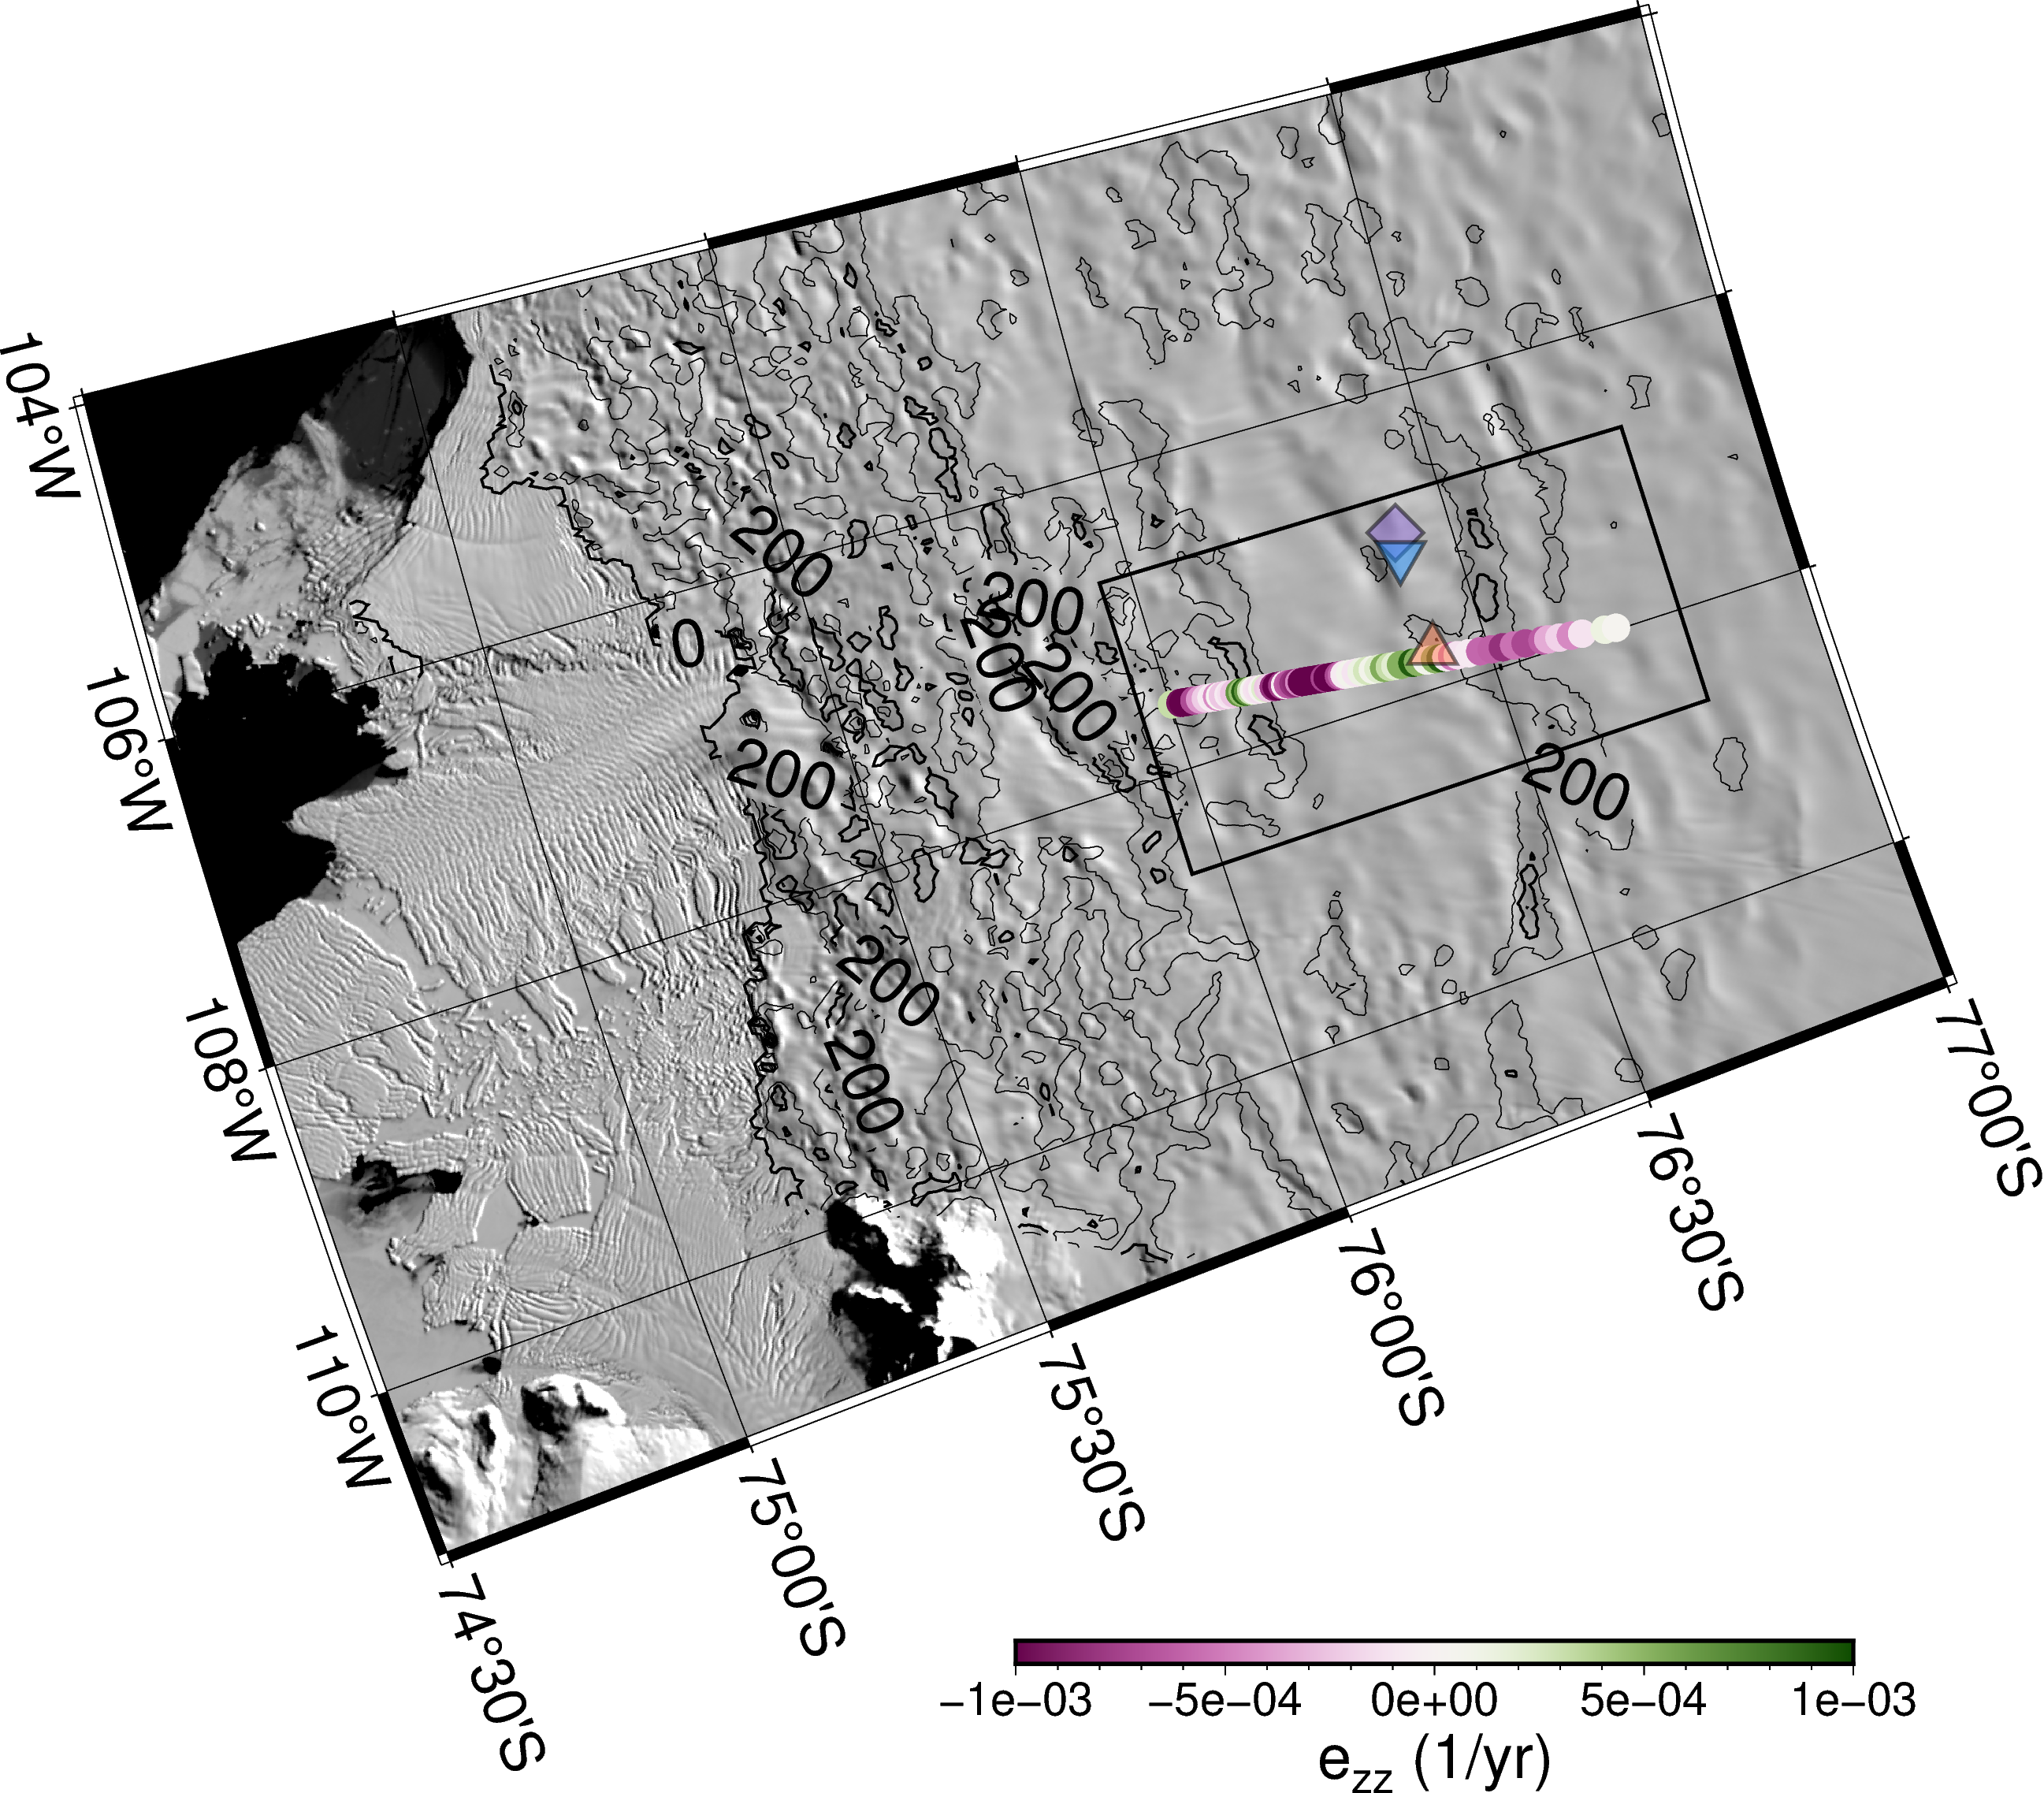

In [24]:
fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY=18,FONT_LABEL=24,
            FORMAT_GEO_MAP="ddd:mm:ssF")
region=[-111,-104,-77,-74.5]
# MODIS image
pygmt.makecpt(cmap="black", series=[0,255],output='mask.cpt')
pygmt.makecpt(cmap="gray", series=[12000, 18000])
fig.grdimage(grid="/home/andrew/Downloads/moa125_2009_hp1.v1.ll.nc",region=region, projection="s0/-90/-71/1:1.6e6")

ds=rxr.open_rasterio("/home/andrew/joughin_2014_taub_clip.tif")

fig.grdcontour(grid=ds/1000,region=region,  projection="s0/-90/-71/1:1.6e6",levels=100, annotation="200+f20p")



#region3=[-110,-105,-76.5,-75.25]
#region4=[-108.35,-107.5,-76.35,-76.05]

#rectangle3 = [[region3[0], region3[2], region3[1], region3[3]]]

fig.basemap(region=region, projection="s0/-90/-71/1:1.6e6", frame=["xa2f2g2","ya.5f.5g.5"])

#color=iter(cm.rainbow(np.linspace(0,1,len(repeats))))




pygmt.makecpt(cmap="bam", series=[-1e-3, 1e-3])
fig.plot(x=repeats['xcoord'],y=repeats['ycoord'],fill=repeats['a2']/thickness,cmap=True,style="c0.3c")

fig.plot(x=-107.748886,y=-76.415769,fill='coral',style="t.6c",pen="1p,black",transparency=50)
fig.plot(x=-106.933449,y=-76.414723,fill='mediumpurple',style="d.6c",pen="1p,black",transparency=50)
fig.plot(x=-107.092143,y=-76.411538,fill='dodgerblue',style="i.6c",pen="1p,black",transparency=50)



region2 = [160,340,-90,-60]
region3 = [-108.65,-106.69,-76.8,-75.95]

rectangle = [[region3[0], region3[2], region3[1], region3[3]]]
fig.plot(data=rectangle,region=region,projection="s0/-90/-71/1:1.6e6",straight_line='m', style="r+s", pen="1p,black")
pygmt.config(FORMAT_FLOAT_MAP="%1.0e")
fig.colorbar(cmap=True,position="x10.0c/-1.20c+w9c/.25c+h", frame=[r'x+l e@-zz@- (1/yr)+f26'])



speed=pygmt.makecpt(cmap="amp", series=[0.0, 3000])

"""
with fig.inset(position="jBR+w5.2c+o9.3c/-2.3c",no_clip=True):
    # All plotting here in the with-context manager will
    # be in the inset cut-out. This example uses the
    # azimuthal orthogonal projection centered at 10W, 60N.
    fig.grdimage(grid="/home/andrew/Downloads/ant_vel_resamp_epsg4326.grd",region=region2,projection="s0/-90/-71/1:5.2e7",cmap=speed,nan_transparent=True)
    fig.colorbar(cmap=speed,position="1.0c/.75c+w4c/.25c+h", frame=['x+lspeed (m/yr)'])
   
    fig.coast(
        shorelines="0.5p,black",
        region=region2,
        projection="s0/-90/-71/1:5.2e7"
    )
    rectangle = [[region[0], region[2], region[1], region[3]]]
    fig.plot(data=rectangle,region=region2,projection="s0/-90/-71/1:5.2e7",straight_line='m', style="r+s", pen="2p,black")

    #pig￼
    #fig.plot(x=np.array([-91.99776,-96.8947735,-101.56351,-97.0496292]),y=np.array([-75.37642,-73.5696493,-74.36166,-76.2770031]),region=region2,projection="s0/-90/-71/1:9e7",color='pink', style="a.3c", pen=".5p,black")
    #thwaites
    #fig.plot(x=np.array([-119-31/60]),y=np.array([-80-1/60]),region=region2,projection="s0/-90/-71/1:9e7",color='dodgerblue', style="a.3c", pen=".5p,black")
    #dotson
    #fig.plot(x=np.array([-91.99776,-96.8947735,-101.56351,-97.0496292]),y=np.array([-75.37642,-73.5696493,-74.36166,-76.2770031]),region=region2,projection="s0/-90/-71/1:9e7",color='pink', style="a.3c", pen=".5p,black")
"""
fig.savefig('../figures/fig01_overview.png',transparent=True)
fig.show()

/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/pygmt/src/grdcontour.py:169: RuntimeWarning: Input image has dtype: float64 which is unsupported, and may result in an incorrect output. Please recast image to a uint8 dtype and/or scale to 0-255 range, e.g. using a histogram equalization function like skimage.exposure.equalize_hist.
  with lib.virtualfile_in(check_kind="raster", data=grid) as vingrd:
PSL: Warning: Sub-scripting not terminated [ @~e�zz@- \(1/yr\)]
PSL: Warning: Symbol font change not terminated [ @~e�zz@- \(1/yr\)]
PSL: Warning: Sub-scripting not terminated [ @~e-zz@- (1/yr)]
PSL: Warning: Symbol font change not terminated [ @~e-zz@- (1/yr)]


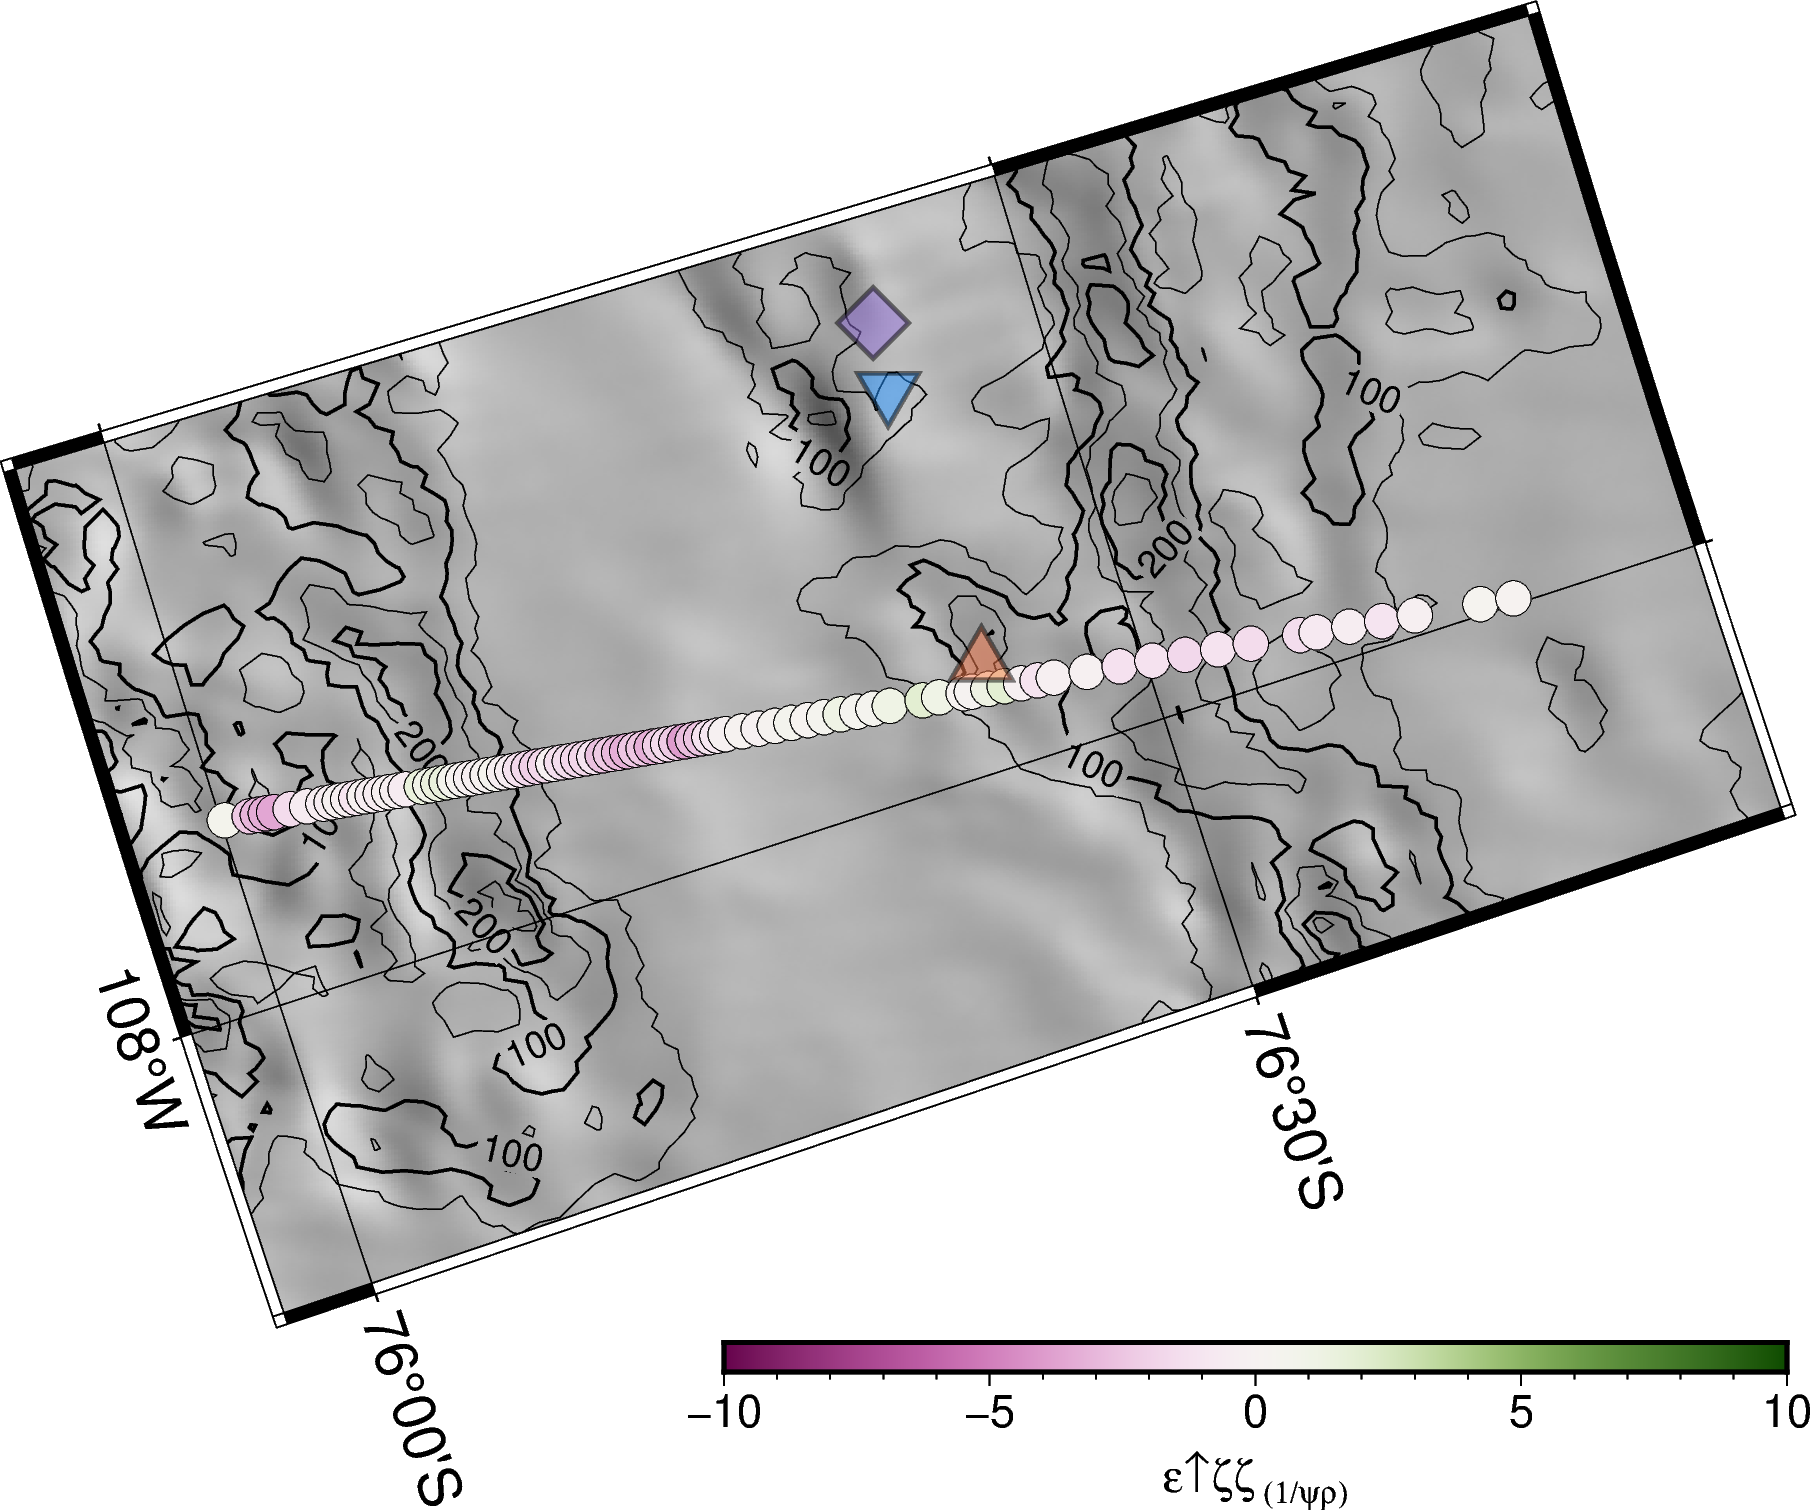

In [25]:
fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY=14,
            FORMAT_GEO_MAP="ddd:mm:ssF")
region= [-108.65,-106.69,-76.8,-75.95]
# MODIS image
pygmt.makecpt(cmap="black", series=[0,255],output='mask.cpt')
pygmt.makecpt(cmap="gray", series=[12000, 18000])

fig.grdimage(grid="/home/andrew/Downloads/moa125_2009_hp1.v1.ll.nc",region=region,  projection="s0/-90/-71/1:7.0e5",)

#region3=[-110,-105,-76.5,-75.25]
#region4=[-108.35,-107.5,-76.35,-76.05]

#rectangle3 = [[region3[0], region3[2], region3[1], region3[3]]]



fig.basemap(region=region, projection="s0/-90/-71/1:7.0e5", frame=["xa2f2g2","ya.5f.5g.5"])

ds=rxr.open_rasterio("/home/andrew/joughin_2014_taub_clip.tif")
fig.grdcontour(grid=ds/1000,region=region,  projection="s0/-90/-71/1:7.0e5",levels=50, annotation=100)


#color=iter(cm.rainbow(np.linspace(0,1,len(repeats))))

#fig.plot(x=-107.748886,y=-76.415769,fill='coral',style="t.6c",pen="1p,black",transparency=50)
#fig.plot(x=-106.933449,y=-76.414723,fill='mediumpurple',style="d.6c",pen="1p,black",transparency=50)
#fig.plot(x=-107.092143,y=-76.411538,fill='dodgerblue',style="i.6c",pen="1p,black",transparency=50)


pygmt.makecpt(cmap="bam", series=[-10, 10])
fig.plot(x=repeats['xcoord'],y=repeats['ycoord'],fill=repeats['a2'],cmap=True,style="c0.3c",pen=".05p,black")

fig.plot(x=-107.748886,y=-76.415769,fill='coral',style="t.6c",pen="1p,black",transparency=50)
fig.plot(x=-106.933449,y=-76.414723,fill='mediumpurple',style="d.6c",pen="1p,black",transparency=50)
fig.plot(x=-107.092143,y=-76.411538,fill='dodgerblue',style="i.6c",pen="1p,black",transparency=50)




rectangle = [[region3[0], region3[2], region3[1], region3[3]]]
fig.colorbar(cmap=True,position="x6c/-.5c+w9c/.25c+h", frame=[r'x+l @~e-zz@- (1/yr)'])
 
fig.savefig('../figures/fig02.png',transparent=True,dpi=300)
fig.show()

/home/andrew/anaconda3/envs/apres/lib/python3.12/site-packages/pygmt/src/grdcontour.py:169: RuntimeWarning: Input image has dtype: float64 which is unsupported, and may result in an incorrect output. Please recast image to a uint8 dtype and/or scale to 0-255 range, e.g. using a histogram equalization function like skimage.exposure.equalize_hist.
  with lib.virtualfile_in(check_kind="raster", data=grid) as vingrd:


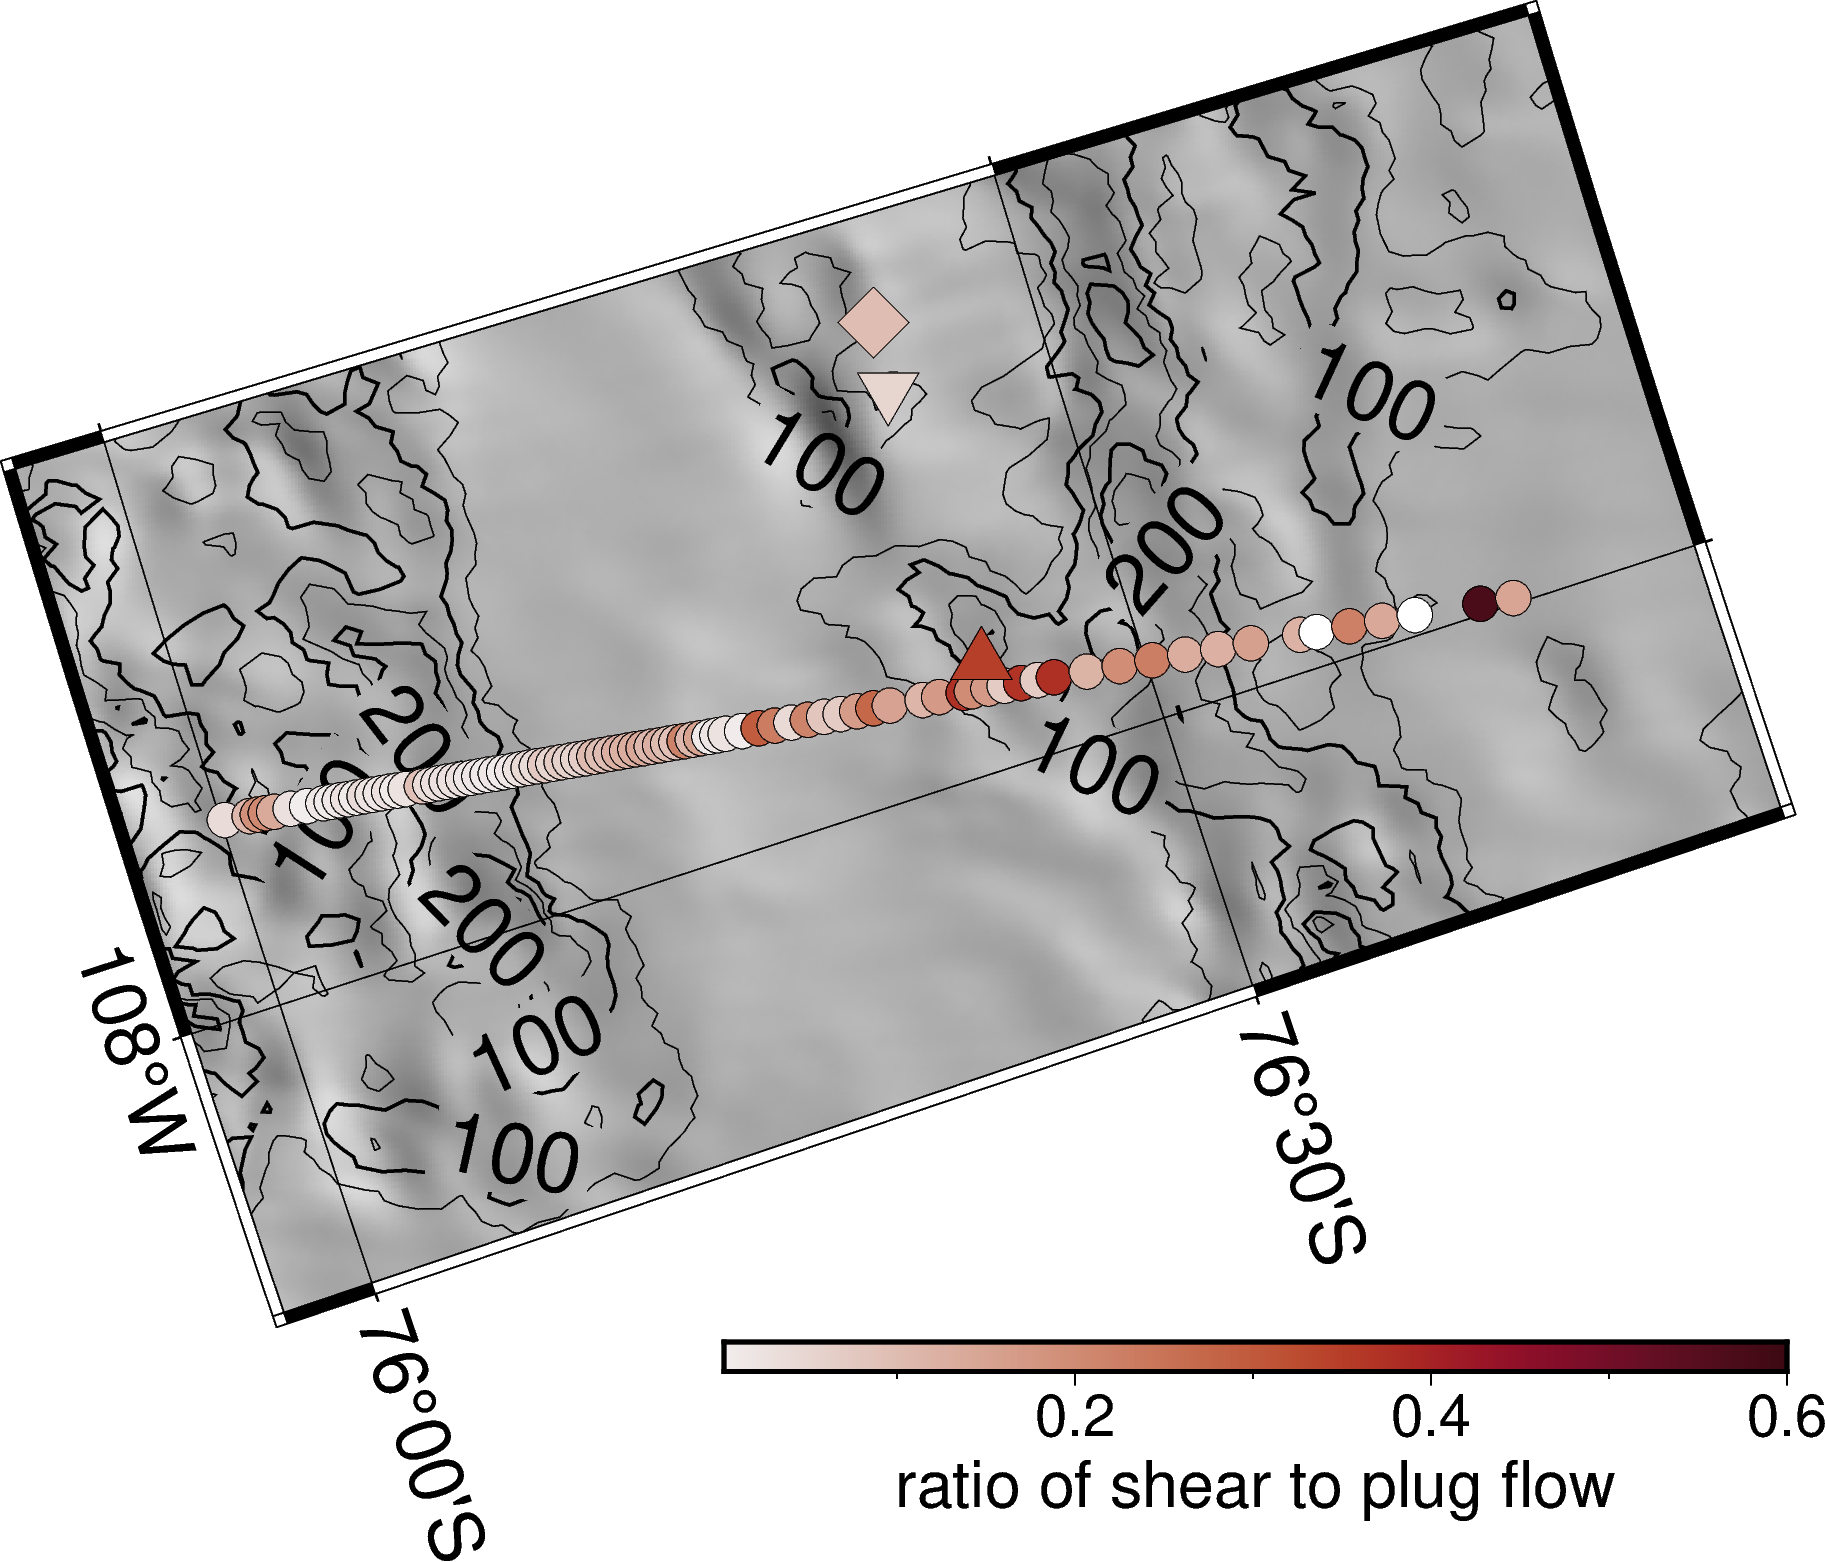

In [26]:
fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY=18,FONT_LABEL=20,
            FORMAT_GEO_MAP="ddd:mm:ssF")
region= [-108.65,-106.69,-76.8,-75.95]
# MODIS image
pygmt.makecpt(cmap="black", series=[0,255],output='mask.cpt')
pygmt.makecpt(cmap="gray", series=[12000, 18000])

fig.grdimage(grid="/home/andrew/Downloads/moa125_2009_hp1.v1.ll.nc",region=region, projection="s0/-90/-71/1:7.0e5",)

#region3=[-110,-105,-76.5,-75.25]
#region4=[-108.35,-107.5,-76.35,-76.05]

#rectangle3 = [[region3[0], region3[2], region3[1], region3[3]]]
shear=1 - (np.abs(repeats['d1']) + np.abs(repeats['d2']))/(np.abs(repeats['d1'])+np.abs(repeats['d2'])+np.abs(repeats['d3']) + np.abs(repeats['d4'])+ np.abs(repeats['d5']))
#shear= (np.abs(repeats['c3']+repeats['c4']))/(np.abs(repeats['c1'])+np.abs(repeats['c2'])+np.abs(repeats['c3'])+np.abs(repeats['c4']))

fig.basemap(region=region, projection="s0/-90/-71/1:7.0e5", frame=["xa2f2g2","ya.5f.5g.5"])

#color=iter(cm.rainbow(np.linspace(0,1,len(repeats))))

ds=rxr.open_rasterio("/home/andrew/joughin_2014_taub_clip.tif")

fig.grdcontour(grid=ds/1000,region=region,  projection="s0/-90/-71/1:7.0e5",levels=50, annotation="100+f20p")

pygmt.makecpt(cmap="amp", series=[np.min(shear), .6])
fig.plot(x=repeats['xcoord'],y=repeats['ycoord'],fill=shear,cmap=True,style="c0.3c",pen=".05p,black")

data1 = pd.DataFrame({"x": [-107.748886], "y": [-76.415769], "z": [.35]})
data2 =  pd.DataFrame({"x": [-106.933449], "y": [-76.414723], "z": [.1]})
data3 =  pd.DataFrame({"x": [-107.092143], "y": [-76.411538], "z": [.05]})

pygmt.makecpt(cmap="amp", series=[np.min(shear), .6])


fig.plot(data=data1,fill=.6,style="t0.6c",pen=".05p,black",cmap=True)
pygmt.makecpt(cmap="amp", series=[np.min(shear), .6])
fig.plot(data=data2,fill=.4,style="d0.6c",pen=".05p,black",cmap=True)
pygmt.makecpt(cmap="amp", series=[np.min(shear), .6])
fig.plot(data=data3,fill=.1,style="i0.6c",pen=".05p,black",cmap=True)



rectangle = [[region3[0], region3[2], region3[1], region3[3]]]
fig.colorbar(cmap=True,position="x6c/-.5c+w9c/.25c+h", frame=['x+lratio of shear to plug flow'])
 
fig.savefig('../figures/fig03.png',transparent=True,dpi=300)
fig.show()

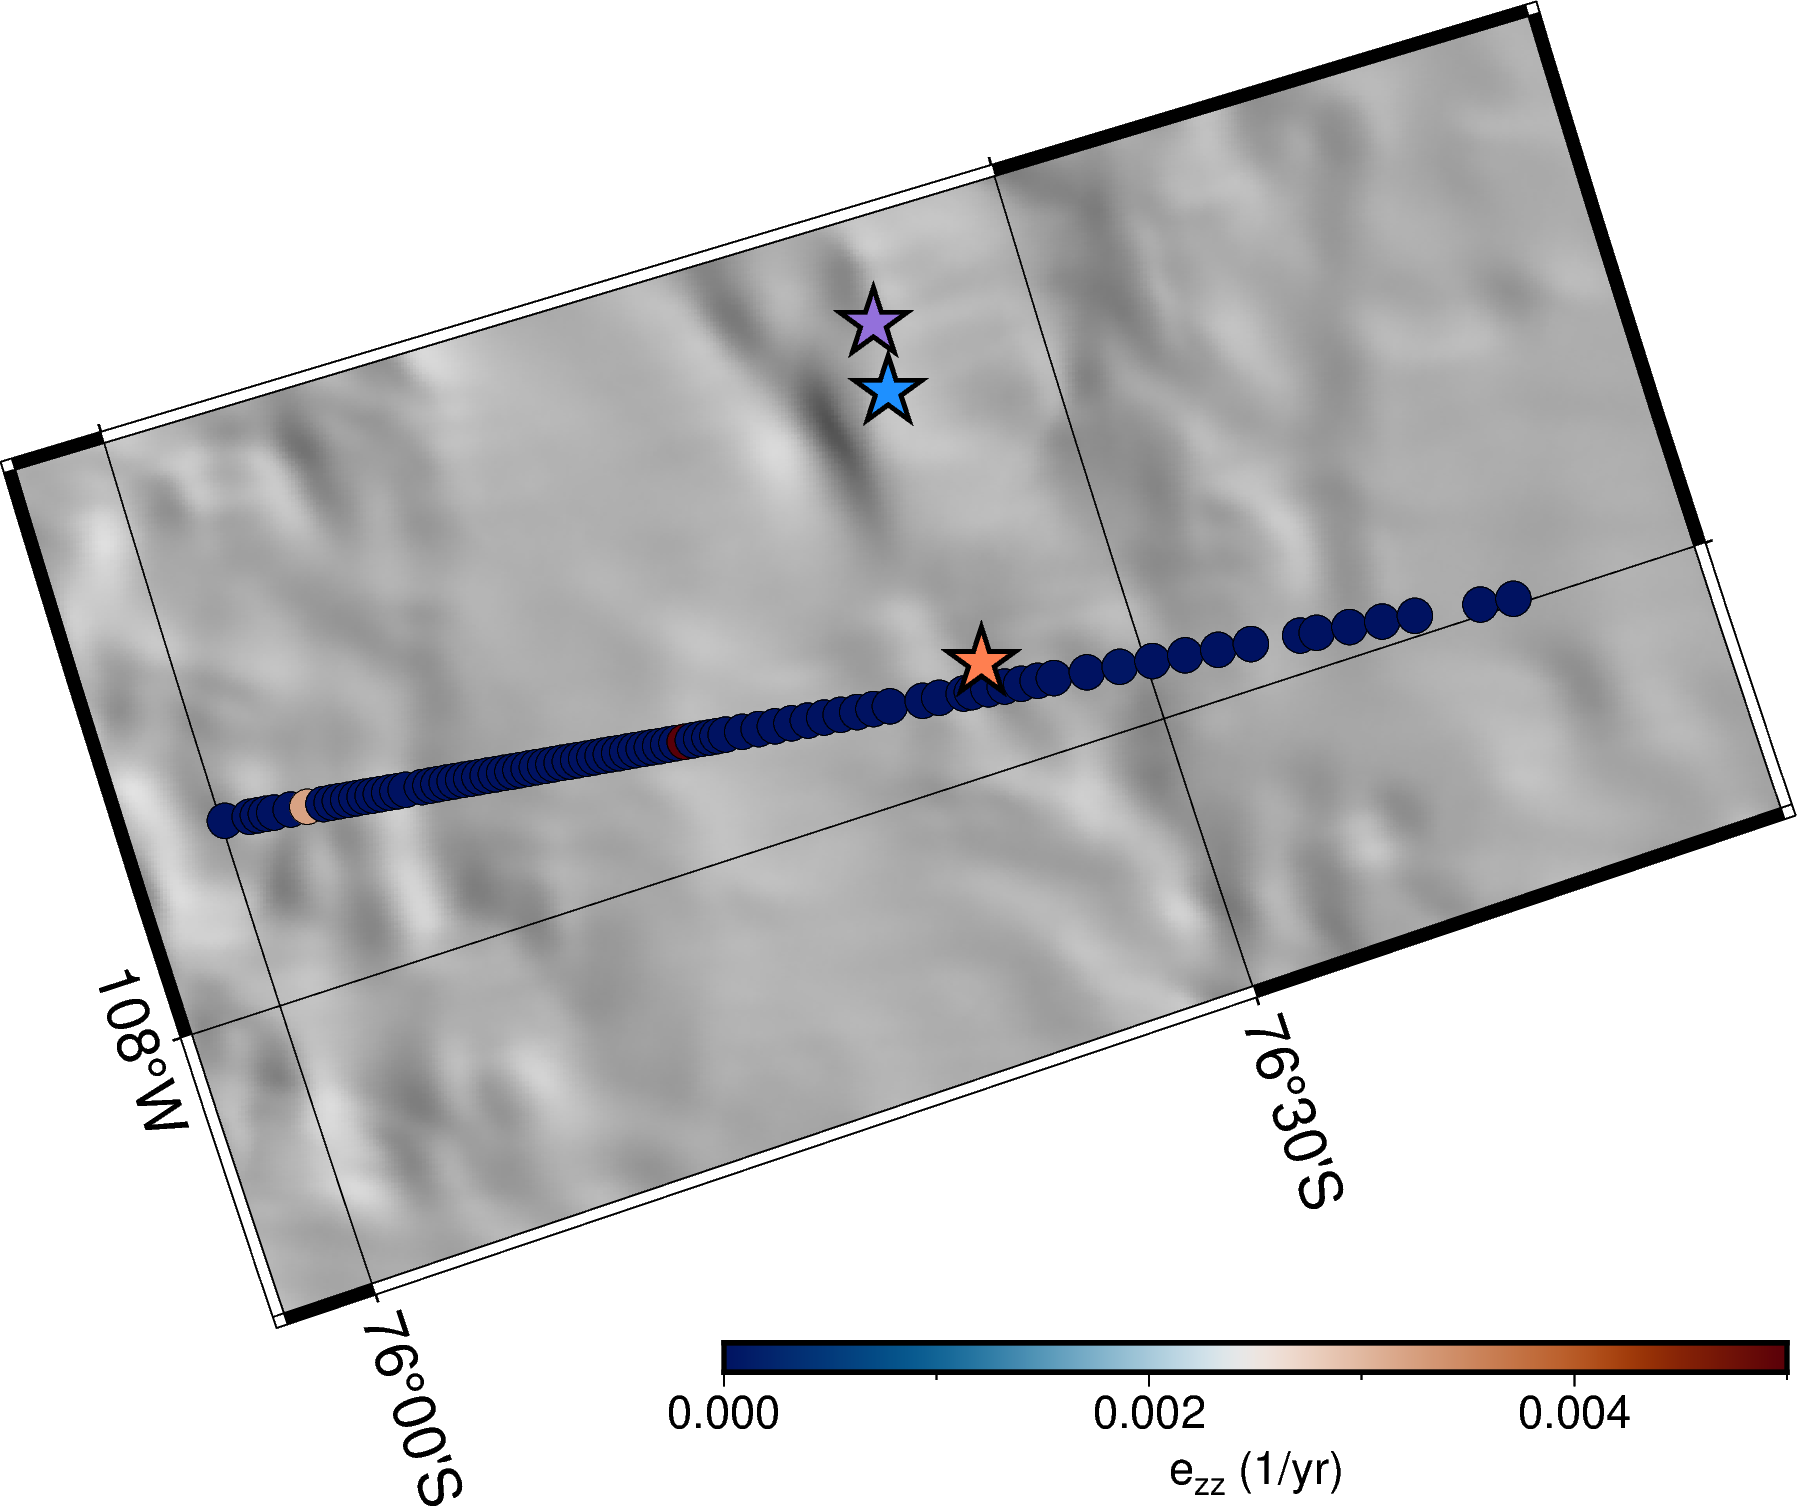

In [27]:
fig = pygmt.Figure()
pygmt.config(FONT_ANNOT_PRIMARY=14,
            FORMAT_GEO_MAP="ddd:mm:ssF")
region= [-108.65,-106.69,-76.8,-75.95]
# MODIS image
pygmt.makecpt(cmap="black", series=[0,255],output='mask.cpt')
pygmt.makecpt(cmap="gray", series=[12000, 18000])

fig.grdimage(grid="/home/andrew/Downloads/moa125_2009_hp1.v1.ll.nc",region=region,  projection="s0/-90/-71/1:7.0e5",)

#region3=[-110,-105,-76.5,-75.25]
#region4=[-108.35,-107.5,-76.35,-76.05]

#rectangle3 = [[region3[0], region3[2], region3[1], region3[3]]]

fig.basemap(region=region, projection="s0/-90/-71/1:7.0e5", frame=["xa2f2g2","ya.5f.5g.5"])

#color=iter(cm.rainbow(np.linspace(0,1,len(repeats))))

pygmt.makecpt(cmap="vik", series=[0, .005])
fig.plot(x=repeats['xcoord'],y=repeats['ycoord'],fill=repeats['f_prob3'],cmap=True,style="c0.3c",pen=".05p,black")


fig.plot(x=-107.748886,y=-76.415769,fill='coral',style="a.6c",pen="1p,black")
fig.plot(x=-106.933449,y=-76.414723,fill='mediumpurple',style="a.6c",pen="1p,black")
fig.plot(x=-107.092143,y=-76.411538,fill='dodgerblue',style="a.6c",pen="1p,black")



rectangle = [[region3[0], region3[2], region3[1], region3[3]]]
fig.colorbar(cmap=True,position="x6c/-.5c+w9c/.25c+h", frame=[r'x+l e@-zz@- (1/yr)'])
 
fig.savefig('../figures/fig02.png',transparent=True,dpi=300)
fig.show()

In [29]:
import matplotlib.pyplot as plt
import numpy as np
plt.clf()
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
# Plot model fits
ax.plot(xdata, linearfit(xdata, repeats['a2'], repeats['a1']), label="Linear fit", color='blue', linestyle='-', linewidth=2)
ax.plot(xdata, squarefit(xdata, repeats['b3'], repeats['b2'], repeats['b1']), label="Quadratic fit", color='green', linestyle='--', linewidth=2)
ax.plot(xdata, cubicfit(xdata, repeats['c4'], repeats['c3'],repeats['c2'], repeats['c1']), label="Cubic fit", color='red', linestyle='-.', linewidth=2)
ax.plot(xdata, quarticfit(xdata, repeats['d5'], repeats['d4'], repeats['d3'], repeats['d2'], repeats['d1']), label="Quartic fit", color='purple', linestyle=':', linewidth=2)

# Plot data with error bars
ax.errorbar(xdata, ydata, yerr=yerr, fmt='ko', label="Data", markersize=5, elinewidth=2)


# Customize the plot
ax.set_title("Velocity Profile with Model Fits and Data Uncertainty")
ax.set_xlabel("Normalized Depth (ζ)")
ax.set_ylabel("Velocity (m/yr)")
ax.grid(True)

# Set limits and invert y-axis
ax.set_ylim(0, 1)
ax.set_xlim(np.min(xdata), np.max(xdata))
ax.invert_yaxis()

# Add legend
ax.legend()
plt.show()


NameError: name 'xdata' is not defined

In [30]:
plot_model_with_data(xdata, ydata, yerr, linearfit, squarefit, cubicfit, quarticfit, a, b, c, d, a_err, b_err, c_err, d_err)


NameError: name 'plot_model_with_data' is not defined